In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import os

#-----------------------------------------------------------------

# Neural Networks
from sklearn.neural_network import MLPRegressor

# Stratified K-Fold
from sklearn.model_selection import StratifiedKFold, train_test_split

# Time
import time

#-----------------------------------------------------------------


#Model evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, mean_absolute_percentage_error
import statsmodels.api as sm

# Load Created Functions
from functions import *

# Set random seed for reproducibility
np.random.seed(40111) 

In [5]:
# Define relative path to the preprocessed data folder (outside "notebooks/")
data_path = "../data_feature_selected/"

# Load preprocessed datasets
X_train = pd.read_csv(f"{data_path}X_train_final.csv", index_col=0)
X_val   = pd.read_csv(f"{data_path}X_val_final.csv", index_col=0)
test    = pd.read_csv(f"{data_path}test_final.csv", index_col=0)

# Load target variables and squeeze to convert DataFrame to Series since they have only one column
y_train = pd.read_csv(f"{data_path}y_train.csv", index_col=0).squeeze()
y_val   = pd.read_csv(f"{data_path}y_val.csv", index_col=0).squeeze()

In [ ]:
# Create a function to fit the model on both training and validation data and measure training time
def model_fit(model, X_train, y_train, X_val, y_val):
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training time: {training_time:.2f} seconds")
    return model

# Hidden Layer Size

In [ ]:
# MLPRegressor(hidden_layer_sizes=(100,)) - demoram mais tempo a correr e não obtemos valores assim tão bons
# MLPRegressor(hidden_layer_sizes=(50, 50)) - demoram mais tempo a correr e não obtemos valores assim tão bons


model_hls_1 = MLPRegressor(hidden_layer_sizes=(30,20))
model_hls_2 = MLPRegressor(hidden_layer_sizes=(40, 30, 20, 10))
model_hls_3 = MLPRegressor(hidden_layer_sizes=(40,30))



# MLPRegressor(hidden_layer_sizes=(40, 30, 20, 10, 5))
# MLPRegressor(hidden_layer_sizes=(40, 30, 20))
# MLPRegressor(hidden_layer_sizes=(50, 10, 10, 10))
# MLPRegressor(hidden_layer_sizes=(50, 30, 20, 10))
# MLPRegressor(hidden_layer_sizes=(10, 20, 30, 40))
# MLPRegressor(hidden_layer_sizes=(5, 10, 20, 30)) - PÉSSIMO
# MLPRegressor(hidden_layer_sizes=(20, 20))
# MLPRegressor(hidden_layer_sizes=(20, 20, 20))
# MLPRegressor(hidden_layer_sizes=(20, 20, 20, 20))
# MLPRegressor(hidden_layer_sizes=(30, 20, 10))
# MLPRegressor(hidden_layer_sizes=(10, 10, 10, 10)) - ficou pior que o (20,20,20)
# MLPRegressor(hidden_layer_sizes=(30,30)) - ficou pior que o (20,20)
# MLPRegressor(hidden_layer_sizes=(10, 10)) - ficou pior que o (20,20)
# MLPRegressor(hidden_layer_sizes=(10, 10, 10)) - ficou pior que o (20,20,20)

In [70]:
model_fit(model_hls_1, X_train, y_train, X_val, y_val)
comparison_metrics(model_hls_1, X_train, y_train, X_val, y_val)

Training time: 33.97 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,8.860799e-01,8.809257e-01,200
1,Adjusted R2,8.859580e-01,8.804141e-01,200
2,MAE,1.854041e+03,1.898783e+03,200
3,MSE,1.073300e+07,1.157047e+07,200
4,RMSE,3.276126e+03,3.401539e+03,200
5,MedAE,1.136911e+03,1.141249e+03,200
6,MAPE (%),1.134262e-01,1.152482e-01,200


In [ ]:
model_fit(model_hls_2, X_train, y_train, X_val, y_val)
comparison_metrics(model_hls_2, X_train, y_train, X_val, y_val)
#acho que o modelo overfitta um pouco

Training time: 74.02 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,9.213186e-01,9.121509e-01,200
1,Adjusted R2,9.212344e-01,9.117735e-01,200
2,MAE,1.599480e+03,1.711005e+03,200
3,MSE,7.412982e+06,8.536310e+06,200
4,RMSE,2.722679e+03,2.921696e+03,200
5,MedAE,1.010282e+03,1.042485e+03,200
6,MAPE (%),9.931865e-02,1.049856e-01,200


# Activation Function

Da aula o stor disse que a linear não vale a pena usar pq faz o mesmo que uma regressão linear simples.
A Relu é a default ou seja já foi testada antes.
Relativamente às outras o chat diz que:
- `tanh` é útil se os dados forem padronizados com média zero. Pode ser interessante se você quiser saídas centralizadas em torno de zero, mas treina um pouco mais devagar que relu.
- `logistic` Não recomendado para regressão contínua, porque satura rapidamente e dificulta o aprendizado.

Aqui vamos começar por usar o hidden_layer_size que "escolhemos" acima.

In [51]:
model_act_1 = MLPRegressor(hidden_layer_sizes=(40, 30, 20, 10), activation='tanh')
model_fit(model_act_1, X_train, y_train, X_val, y_val)
comparison_metrics(model_act_1, X_train, y_train, X_val, y_val)

Training time: 58.09 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,-2.785492e+00,-2.714439e+00,200
1,Adjusted R2,-2.789545e+00,-2.730397e+00,200
2,MAE,1.619988e+04,1.624081e+04,200
3,MSE,3.566509e+08,3.609325e+08,200
4,RMSE,1.888520e+04,1.899822e+04,200
5,MedAE,1.401616e+04,1.412616e+04,200
6,MAPE (%),9.466314e-01,9.468867e-01,200


In [58]:
model_act_2 = MLPRegressor(hidden_layer_sizes=(20, 10), activation='tanh')
model_fit(model_act_1, X_train, y_train, X_val, y_val)
comparison_metrics(model_act_1, X_train, y_train, X_val, y_val)

Training time: 60.19 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,-2.786589e+00,-2.715505e+00,200
1,Adjusted R2,-2.790643e+00,-2.731468e+00,200
2,MAE,1.620307e+04,1.624400e+04,200
3,MSE,3.567543e+08,3.610361e+08,200
4,RMSE,1.888794e+04,1.900095e+04,200
5,MedAE,1.401935e+04,1.412935e+04,200
6,MAPE (%),9.468833e-01,9.471368e-01,200


PÉSSIMOS RESULTADOS. Valores de R2 negativos o que mostra o quão maus são os nossos resultados

# Max_Iter

Percebemos antes que todos os modelos testados convergem. Ou seja, se puderem fazer mais iterações talvez obtenham melhores resultados. Aqui vamos então testar diferentes nº de iterações.

Começamos por usar o melhor hidden layer e a activation function RELU que é a default.

In [83]:
model_maxiter_1 = MLPRegressor(hidden_layer_sizes=(40, 30, 20, 10), activation='relu', max_iter=300)
model_fit(model_maxiter_1, X_train, y_train, X_val, y_val)
comparison_metrics(model_maxiter_1, X_train, y_train, X_val, y_val)
# o resultado obtido do MAE foi pior do que com apenas 200 iterações e pelos valores de R2 parece que o modelos overfitta

Training time: 79.98 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
0,R2,9.291214e-01,9.162746e-01,300
1,Adjusted R2,9.290455e-01,9.159148e-01,300
2,MAE,1.552918e+03,1.675262e+03,300
3,MSE,6.677840e+06,8.135614e+06,300
4,RMSE,2.584152e+03,2.852300e+03,300
5,MedAE,1.001938e+03,1.043596e+03,300
6,MAPE (%),9.744003e-02,1.042298e-01,300


In [81]:
model_maxiter_2 = MLPRegressor(hidden_layer_sizes=(30, 20), activation='relu', max_iter=300)
model_fit(model_maxiter_2, X_train, y_train, X_val, y_val)
comparison_metrics(model_maxiter_2, X_train, y_train, X_val, y_val)[2:]

Training time: 50.67 seconds


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,Metric,Train,Validation,Iteration
2,MAE,1.846986e+03,1.899604e+03,300
3,MSE,1.077087e+07,1.177519e+07,300
4,RMSE,3.281901e+03,3.431500e+03,300
5,MedAE,1.112233e+03,1.127432e+03,300
6,MAPE (%),1.136445e-01,1.155156e-01,300


<Axes: >

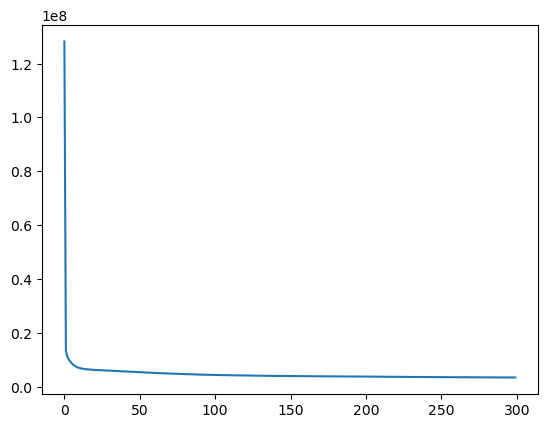

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

losses = model_maxiter_1.loss_curve_
iterations = range(model_maxiter_1.n_iter_)
sns.lineplot(x = iterations, y = losses)